## 3.1 변분 양자 고유값 풀이 (Variational Quantum Eigensolver, VQE)

In [1]:
# 필요한 라이브러리 불러오기
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.primitives import StatevectorEstimator as Estimator  # 호환성 수정(qiskit 2.x): V1 Estimator → StatevectorEstimator
from qiskit.circuit.library import EfficientSU2
from qiskit_algorithms.optimizers import COBYLA
from qiskit.quantum_info import SparsePauliOp, Pauli
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline 

In [2]:
# 시스템의 해밀토니안 정의
# 이 예제에서는 간단한 해밀토니안 H = ZI + IZ + ZZ 사용
pauli_list = [Pauli('ZI'), Pauli('IZ'), Pauli('ZZ')]
coefficients = [1.0, 1.0, 1.0]
H = SparsePauliOp(pauli_list, coefficients)

In [3]:
# 변분 안사츠용 양자 회로 정의
num_qubits = 2
ansatz = EfficientSU2(num_qubits, entanglement='linear')

/sessions/eloquent-vigilant-lovelace/tmp/ipykernel_46/692989635.py:3: DeprecationWarning: The class ``qiskit.circuit.library.n_local.efficient_su2.EfficientSU2`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.efficient_su2 instead.
  ansatz = EfficientSU2(num_qubits, entanglement='linear')


In [4]:
# 시뮬레이터 초기화
simulator = AerSimulator()

In [5]:
# 옵티마이저 정의
optimizer = COBYLA(maxiter=200)

In [6]:
# 해밀토니안 기댓값을 계산하는 함수
def objective_function(params):
    bound_circuit = ansatz.assign_parameters(params)
    estimator = Estimator()
    # 호환성 수정(qiskit 2.x): V2 Estimator는 [(회로, 관측량)] 형태로 받고 .data.evs 로 기댓값을 반환
    result = estimator.run([(bound_circuit, H)]).result()
    return float(np.real(result[0].data.evs))

In [7]:
# 초기 파라미터
initial_params = np.random.random(ansatz.num_parameters)

In [8]:
# 해밀토니안 기댓값을 최소화하도록 파라미터 최적화
result = optimizer.minimize(objective_function, initial_params)

In [9]:
# 최적화된 파라미터와 그에 해당하는 최소 에너지 얻기
optimized_params, minimum_energy = result.x, result.fun

In [10]:
# 결과 출력
print("Optimized Parameters:", optimized_params)
print("Minimum Energy:", minimum_energy)

Optimized Parameters: [ 1.57858615  0.40880064  0.81819522  1.2304669   0.41309961  1.72514871
  1.78018587  0.40041313  0.67744045  0.75583872 -0.17580714 -0.14862055
  1.14789737  0.6941533   0.48280617  0.93485572]
Minimum Energy: -0.9999999865574094


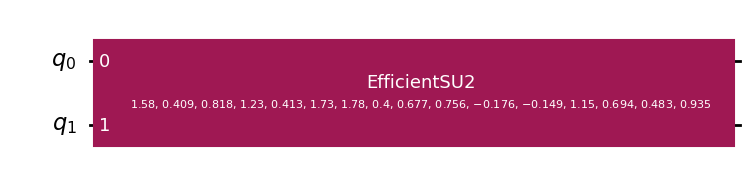

In [11]:
# 최종 회로 시각화
optimized_circuit = ansatz.assign_parameters(optimized_params)
optimized_circuit.draw('mpl')
plt.show()